In [36]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


import RaschPy_aisi 
from RaschPy_aisi import RaschPy as rp
import pandas as pd
import numpy as np
from itertools import combinations
from scipy import stats

import config, os
from config import DATA_DIR, OUTPUT_DIR, OUTPUT_DIR_stats, DIMENSIONS, COLORS, LLM_NAMES, ANNOTATOR_ID_MAP
from Analysis.mfrm_analysis import read_filepaths, creating_mfrm_ready_data, get_severity, plot_human_vs_llm_scatter_theta_new


all_filepaths = read_filepaths(DATA_DIR)

filepath_gold = all_filepaths['gold']
filepath_gemini_modu= all_filepaths['gemini_modu']
filepath_gemini_mono= all_filepaths['gemini_mono']
filepath_deepseek_modu= all_filepaths['deepseek_modu']
filepath_deepseek_mono= all_filepaths['deepseek_mono']

pd_dataframes, all_files, concat_df = creating_mfrm_ready_data(filepath_gold, filepath_gemini_mono, filepath_gemini_modu, 
                                                               filepath_deepseek_mono,filepath_deepseek_modu,
                                                               output_dir=OUTPUT_DIR) 


Combined dataset:
Total rows in concatenated filtered df: 1605
Unique comments: 250
Unique raters: 586

checking for missing values

[Problem] WARNING: Missing values detected:
respect          48
insult           48
humiliate        48
status           48
dehumanize       48
violence         48
genocide         48
attack_defend    48
dtype: int64


In [38]:
all_filepaths = read_filepaths(base_dir=OUTPUT_DIR)

def calibrate(filepath, label):
    """Helper to load and calibrate MFRM model."""
    print(f"  Calibrating {label}...")
    data, _ = rp.loadup_mfrm_single(filepath)
    model   = rp.MFRM(data)
    model.calibrate_global()
    return model

gold_data            = str(all_filepaths['gold'])
gemini_mono_data     = str(all_filepaths['gemini_mono'])
gemini_modu_data     = str(all_filepaths['gemini_modu'])
deepseek_mono_data   = str(all_filepaths['deepseek_mono']) 
deepseek_modu_data   = str(all_filepaths['deepseek_modu']) 

# Combined files
llm_human_mod_mono   = str(all_filepaths['llm_human_mod_mono']) # removed 4 here: question for team,
llm_only_mod_mono    = str(all_filepaths['llm_only_mod_mono'])
llm_only_mono        = str(all_filepaths['llm_only_mono'])
llm_only_modu        = str(all_filepaths['llm_only_modu'])
llm_mono_nogpt5      = str(all_filepaths['llm_mono_nogpt5'])

# =============================================================================
# CALIBRATE SEPARATE MODELS WITH MFRM
# =============================================================================
print("\nCalibrating separate models...")

# Individual annotator models
mfrm_humans        = calibrate(gold_data,           'Humans only')
mfrm_gemini_mono   = calibrate(gemini_mono_data,    'Gemini mono')
mfrm_gemini_modu   = calibrate(gemini_modu_data,    'Gemini modu')
mfrm_deepseek_mono = calibrate(deepseek_mono_data,  'DeepSeek mono')
mfrm_deepseek_modu = calibrate(deepseek_modu_data,  'DeepSeek modu')

# Combined models
mfrm_llms_only           = calibrate(llm_only_mod_mono,  'All LLMs mono+modu')
mfrm_llms_mono           = calibrate(llm_only_mono,      'All LLMs mono only')
mfrm_llms_modu           = calibrate(llm_only_modu,      'All LLMs modu only')
mfrm_all                 = calibrate(llm_human_mod_mono, 'All raters combined')

print("\n✓ All models calibrated")
# =============================================================================
# EXTRACT ITEM DIFFICULTIES and determing strictest and most lenient LLMs
# =============================================================================

comparison = pd.DataFrame({
    'humans'           : mfrm_humans.diffs,
    'gemini_mono'      : mfrm_gemini_mono.diffs,
    'gemini_modu'      : mfrm_gemini_modu.diffs,
    'deepseek_mono'    : mfrm_deepseek_mono.diffs,
    'deepseek_modu'    : mfrm_deepseek_modu.diffs,
    'llm_only_mono'    : mfrm_llms_mono.diffs,
    'llm_only_modu'    : mfrm_llms_modu.diffs,
    'llm_only_mod_mono': mfrm_llms_only.diffs,
    'llm_human_all'    : mfrm_all.diffs,
})

# LLM_COLS =LLM_NAMES[:-2]                    

# Human vs LLM mono difference
comparison['Hu_vs_LLM_mono'] = comparison['humans'] - comparison['llm_only_mono']
comparison['interpretation_hu_llm(mono)'] = comparison['Hu_vs_LLM_mono'].apply(
    lambda x: 'LLM Stricter (Finds Harder)' if x < 0 else 'LLM Lenient (Finds Easier)'
)

# Human vs LLM modu difference
comparison['Hu_vs_LLM_modu'] = comparison['humans'] - comparison['llm_only_modu']
comparison['interpretation_hu_llm(modu)'] = comparison['Hu_vs_LLM_modu'].apply(
    lambda x: 'LLM Stricter (Finds Harder)' if x < 0 else 'LLM Lenient (Finds Easier)'
)

LLM_COLS = [col for col in comparison.columns if col in LLM_NAMES] #llm names only contains original llms names

# Rankings
for col in ['humans', 'llm_only_mono', 'llm_only_modu','llm_only_mod_mono']:
    comparison[f'{col}_rank'] = comparison[col].rank()

# =============================================================================
# ITEM DIFFICULTY COMPARISONS
# =============================================================================
print("\n" + "="*80)
print("ITEM DIFFICULTY ANALYSIS")
print("="*80)


all_llms_comparison = {
    # 'GPT5_mono'        : mfrm_GPT5_mono.diffs,
    'gemini_mono'      : mfrm_gemini_mono.diffs,
    'gemini_modu'      : mfrm_gemini_modu.diffs,
    'deepseek_mono'    : mfrm_deepseek_mono.diffs,
    'deepseek_modu'    : mfrm_deepseek_modu.diffs }

all_merged_llms_comparisons={
    'llm_only_mono'    : mfrm_llms_mono.diffs,
    'llm_only_modu'    : mfrm_llms_modu.diffs,
    'llm_only_mod_mono': mfrm_llms_only.diffs,
    'llm_human_all'    : mfrm_all.diffs,
}

print('***Human vs individual LLM correlations***')
for name, mfrm_diffs in all_llms_comparison.items():
    corr_hu_llm = mfrm_humans.diffs.corr(mfrm_diffs)
    print(f"Correlation Human vs {name}: r={corr_hu_llm:.3f}")

print('\n***Human vs combined LLM correlations****')   
for name_merged, mfrm_merged_diffs in all_merged_llms_comparisons.items():
    corr_hu_llm_merged = mfrm_humans.diffs.corr(mfrm_merged_diffs)
    print(f"Correlation Human vs {name_merged}: r={corr_hu_llm_merged:.3f}")


print('\n***Monolithic vs Modular Corrlations****')   

corr_gemini_mono_modu = mfrm_gemini_mono.diffs.corr(mfrm_gemini_modu.diffs)
print(f"Correlation Gemini mono vs modu: r={corr_gemini_mono_modu:.3f}")

corr_deepseek_mono_modu = mfrm_deepseek_mono.diffs.corr(mfrm_deepseek_modu.diffs)
print(f"Correlation DeepSeek mono vs modu: r={corr_deepseek_mono_modu:.3f}")

print("\n\n" + "="*300)
print("FULL ITEM DIFFICULTY COMPARISON TABLE")
print("="*300)
print(comparison.round(3).to_string())


Calibrating separate models...
  Calibrating Humans only...
  Calibrating Gemini mono...
  Calibrating Gemini modu...
  Calibrating DeepSeek mono...
  Calibrating DeepSeek modu...
  Calibrating All LLMs mono+modu...
  Calibrating All LLMs mono only...
  Calibrating All LLMs modu only...
  Calibrating All raters combined...

✓ All models calibrated

ITEM DIFFICULTY ANALYSIS
***Human vs individual LLM correlations***
Correlation Human vs gemini_mono: r=0.907
Correlation Human vs gemini_modu: r=0.927
Correlation Human vs deepseek_mono: r=0.951
Correlation Human vs deepseek_modu: r=0.898

***Human vs combined LLM correlations****
Correlation Human vs llm_only_mono: r=0.929
Correlation Human vs llm_only_modu: r=0.906
Correlation Human vs llm_only_mod_mono: r=0.927
Correlation Human vs llm_human_all: r=0.988

***Monolithic vs Modular Corrlations****
Correlation Gemini mono vs modu: r=0.969
Correlation DeepSeek mono vs modu: r=0.938


FULL ITEM DIFFICULTY COMPARISON TABLE
               huma

In [39]:
stats_path = '../hate-thermometer-anonymous/hate_thermometer_data/outputs/stats'
#item diff joint mfrm
item_path = os.path.join(stats_path, 'ablate_item_diff_fit_stats_joint_mfrm.csv')  
mfrm_all.item_stats_df_global()
mfrm_all.item_stats_global.to_csv(item_path, index=True)  # keep index for clarity
mfrm_all.item_stats_global

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
sentiment,-1.989,0.106,1605,0.754,1.706,1.405
respect,-1.791,0.081,1557,0.697,1.458,1.295
insult,-0.974,0.096,1557,0.612,1.848,1.715
humiliate,-0.209,0.076,1557,0.554,1.888,2.056
status,-0.725,0.091,1557,0.706,1.715,3.526
dehumanize,0.803,0.088,1557,0.359,2.611,2.895
violence,1.577,0.130,1557,0.152,3.286,3.183
genocide,2.345,0.221,1557,0.058,3.144,3.048
attack_defend,-1.159,0.075,1557,0.681,1.291,1.419
hatespeech,2.122,0.109,1605,0.178,1.429,1.661


In [22]:
#item stats for humans only
human_path = os.path.join(stats_path, 'ablate_item_diff_fit_stats_human_only.csv') 
mfrm_humans.item_stats_df_global()
mfrm_humans.item_stats_global.to_csv(human_path, index=True) 
mfrm_humans.item_stats_global

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
sentiment,-1.990,0.111,605,0.721,1.236,1.166
respect,-1.822,0.128,605,0.675,1.343,1.307
insult,-0.785,0.106,605,0.605,1.326,1.344
humiliate,-0.170,0.099,605,0.542,1.514,1.532
status,-0.749,0.100,605,0.636,1.269,1.431
dehumanize,0.485,0.108,605,0.425,1.692,1.675
violence,1.296,0.146,605,0.198,1.895,1.674
genocide,2.037,0.191,605,0.100,1.718,1.571
attack_defend,-0.708,0.091,605,0.621,1.206,1.223
hatespeech,2.407,0.173,605,0.126,1.309,1.245


In [23]:
#separation reliability stats
sep_reliability_path = os.path.join(stats_path, 'ablate_separation_reliabilitiy_joint_mfrm.csv') 
mfrm_all.test_stats_df_global()
mfrm_all.test_stats_global.to_csv(sep_reliability_path, index=True) 
mfrm_all.test_stats_global

,Items,Persons
Mean,0.000,-0.803
SD,1.604,2.101
Separation ratio,14.264,7.280
Strata,19.352,10.040
Reliability,0.995,0.981


In [24]:
#severity measures
severity_series = (
    pd.Series(mfrm_all.severities_global, name='severity')
    .reset_index()
    .rename(columns={'index': 'Rater'})
)

severity_df, severity_for_plotting_2 = get_severity(severity_series)
print(severity_df.tail(10))

Index(['index', 'Rater', 'severity'], dtype='str')
     index                       annotator  severity     rater_type
576    576                            9902 -0.005701          Human
577    577                            9914  1.471517          Human
578    578                            9916 -1.092892          Human
579    579                            9928  0.068455          Human
580    580                            9971 -0.447641          Human
581    581                            9982 -0.742758          Human
582    582  deepseek-v4-flash_modu_no_slur -0.841091  deepseek_modu
583    583  deepseek-v4-flash_mono_no_slur -0.342272  deepseek_mono
584    584                     gemini_modu -1.218533    gemini_modu
585    585                     gemini_mono -0.469161    gemini_mono


In [28]:
severity_path = os.path.join(stats_path, 'ablate_severity_joint_mfrm.csv') 
severity_df.to_csv(severity_path, index=True)

In [25]:
#continuous hate scores theta 

# # =============================================================================
# # EXTRACT ALL THETAS
# # =============================================================================
def extract_theta(mfrm, label=""):
    mfrm.person_stats_df_global()
    theta = mfrm.person_stats_global.get('Estimate')
    theta.index.name = 'comment_id'
    if theta is None or theta.empty:
        raise ValueError(f"No theta estimates found for: {label}")
    return theta
# ── Extract all thetas ────────────────────────────────────────────────────────
thetas_joint =  pd.DataFrame(extract_theta(mfrm_all,           'joint'))


# Merge with Kennedy scores
kennedy_scores = pd_dataframes['gold'][['comment_id', 'hate_speech_score']].set_index('comment_id')
comparison = thetas_joint.reset_index().merge(
    kennedy_scores,
    on='comment_id',
    how='inner'
)
comparison.rename(columns={'hate_speech_score': 'kennedy_theta_score', 'Estimate': 'mfrm_joint_all'}, inplace=True) 

r, p   = stats.pearsonr(comparison['mfrm_joint_all'],
                         comparison['kennedy_theta_score'])
mae    = (comparison['mfrm_joint_all'] - 
          comparison['kennedy_theta_score']).abs().mean()
bias   = (comparison['mfrm_joint_all'] - 
          comparison['kennedy_theta_score']).mean()

print("\n=== Joint θₙ vs Kennedy Gold Standard ===")
print(f"r={r:.3f}  p={p:.6f}  MAE={mae:.3f}  Bias={bias:.3f} size = {len(comparison)}")


=== Joint θₙ vs Kennedy Gold Standard ===
r=0.857  p=0.000000  MAE=0.913  Bias=0.327 size = 605


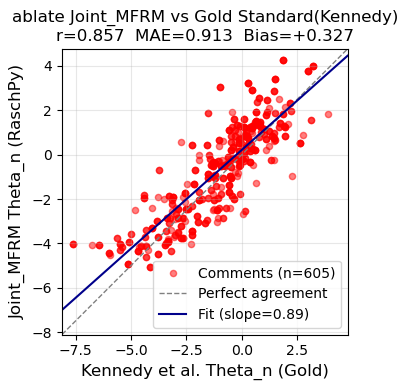

Saved: joint_vs_kennedy_scatter.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os

fig, ax = plt.subplots(figsize=(5, 4))

# ── Scatter points ────────────────────────────────────────
ax.scatter(
    comparison['kennedy_theta_score'],
    comparison['mfrm_joint_all'],
    color='red',
    alpha=0.5,
    s=20,
    label='Comments (n=605)'
)

# ── Perfect agreement line ────────────────────────────────
lims = [
    min(comparison['kennedy_theta_score'].min(),
        comparison['mfrm_joint_all'].min()) - 0.5,
    max(comparison['kennedy_theta_score'].max(),
        comparison['mfrm_joint_all'].max()) + 0.5
]
ax.plot(lims, lims,
        color='gray',
        linestyle='--',
        linewidth=1,
        label='Perfect agreement')

# ── OLS fit line ──────────────────────────────────────────
m, b = np.polyfit(
    comparison['kennedy_theta_score'],
    comparison['mfrm_joint_all'], 1
)
x_fit = np.linspace(lims[0], lims[1], 200)
ax.plot(x_fit, m * x_fit + b,
        color='darkblue',
        linewidth=1.5,
        label=f'Fit (slope={m:.2f})')

# ── Labels and stats ──────────────────────────────────────
ax.set_xlabel('Kennedy et al. Theta_n (Gold)', fontsize=12)
ax.set_ylabel('Joint_MFRM Theta_n (RaschPy)', fontsize=12)
ax.set_title(
    f'ablate Joint_MFRM vs Gold Standard(Kennedy)\n'
    f'r={r:.3f}  MAE={mae:.3f}  Bias={bias:+.3f}',
    fontsize=12
)
ax.legend(fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
theta_path = os.path.join(stats_path, 'ablate_joint_vs_kennedy_scatter.png')
plt.savefig(theta_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved: joint_vs_kennedy_scatter.png")